In [1]:
prefix = '/home/ines/repositories/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/'

In [88]:
""" 
IMPORTS
"""
import os
import numpy as np
import pickle
import pandas as pd
from one.api import ONE
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from matplotlib.colors import ListedColormap
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Get my functions
from functions import idxs_from_files, state_identifiability, align_bin_design_matrix, states_per_trial_phase, broader_label
from functions import define_trial_types, rescale_sequence, plot_binned_sequence

one = ONE(mode='remote')

# Parameters

In [3]:
# LOAD DATA
data_path = prefix + 'representation_learning_variability/paper-individuality/data/design_matrices/'

all_files = os.listdir(data_path)
design_matrices = [item for item in all_files if 'design_matrix' in item and 'standardized' not in item]
idxs, mouse_names = idxs_from_files(design_matrices)

save_states_path = prefix + 'representation_learning_variability/paper-individuality/data/states_files/'

# Individual sessions

In [4]:
# Identify sessions available to process
sessions_to_process = []
for m, mat in enumerate(idxs):
    mouse_name = mat[37:]
    session = mat[:36]
    sessions_to_process.append((mouse_name, session))
print(f"Found {len(sessions_to_process)} sessions to process.")

Found 319 sessions to process.


In [5]:
identifiable_mapping = {}

counter = 0
for lick in [0, 1]:
    for whisk in [0, 1]:
        for paw in range(8):
            key = f"{paw}{whisk}{lick}"
            identifiable_mapping[key] = float(counter)
            counter += 1

identifiable_mapping["nan"] = np.nan
paw_fix_mapping = {0:4, 1:1, 2:5, 3:7, 4:6, 5:2, 6:0, 7:3}  # before extension
paw_fix_mapping = {0:3, 1:1, 2:2, 3:6, 4:7, 5:0, 6:4, 7:5} # 19Mar2026


In [54]:
def psth_style_traces(init, inter, empirical_data, session_trials):
    frame_rate = 60
    
    # Create single subplot
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[12, 4])
    plt.rc('font', size=11)
    
    # Get common data
    wheel_data = empirical_data.loc[empirical_data['Bin']>=init, 'avg_wheel_vel'].reset_index()['avg_wheel_vel']
    # Define all variables with wheel velocity on top
    variables = [
        {'name': 'avg_wheel_vel', 'data': wheel_data, 'color': 'black', 'label': 'Wheel Velocity', 'offset': 20},
        {'name': 'l_paw_x', 'data': empirical_data.loc[empirical_data['Bin']>=init, 'l_paw_x'].reset_index()['l_paw_x'], 'color': "#D8971F", 'label': 'Left Paw X', 'offset': 10},
        {'name': 'r_paw_x', 'data': empirical_data.loc[empirical_data['Bin']>=init, 'r_paw_x'].reset_index()['r_paw_x'], 'color': "#54AA0E", 'label': 'Right Paw X', 'offset': 0},
        {'name': 'whisker_me', 'data': empirical_data.loc[empirical_data['Bin']>=init, 'whisker_me'].reset_index()['whisker_me'], 'color': "#b8b8b8",'label': 'Whisking', 'offset': -10},
        {'name': 'Lick count', 'data': empirical_data.loc[empirical_data['Bin']>=init, 'Lick count'].reset_index()['Lick count'], 'color': "#484949",'label': 'Lick Count', 'offset': -20}
    ]
    
    # Plot all variables with z-score normalization and vertical offsets
    y_labels = []
    y_positions = []
    
    for var in variables:
        var_data = var['data']
        
        # Z-score normalize all signals
        var_data_norm = (var_data - var_data.mean()) / var_data.std()
        if var['name'] == 'whisker_me':
            var_data_norm = var_data_norm * 3
        elif var['name'] == 'r_paw_x':
            var_data_norm = var_data_norm + 8
        # Plot with vertical offset
        ax.plot(var_data_norm + var['offset'], color=var['color'], linewidth=2, alpha=0.8)
        
        # Store label positions for y-axis
        y_labels.append(var['label'])
        y_positions.append(var['offset'])
    
    # Calculate overall y-limits with more space
    plot_min = -30
    plot_max = 30
    
    # Event line colors
    vline_colors = {
        'stim_on': "#000000",
        'correct': "#000000", 
        'incorrect': '#e24a4a',
        'first_movement': "#464343",
        'trial_end': "#000000",
        'quiescence': "#000000"
    }
    
    # Add trial event vertical lines - stim on will be at y=0
    stim_line = ax.vlines(np.array(session_trials['goCueTrigger_times'] - init) * frame_rate, 
                         plot_min, plot_max, label='Stim On', color=vline_colors['stim_on'], linewidth=2)
    correct_line = ax.vlines(np.array(session_trials.loc[session_trials['feedbackType']==1, 'feedback_times'] * frame_rate) - init * frame_rate, 
                           plot_min, plot_max, label='Feedback', color=vline_colors['correct'], linewidth=2,  linestyle='dashed')
    incorrect_line = ax.vlines(np.array(session_trials.loc[session_trials['feedbackType']==-1, 'feedback_times'] * frame_rate) - init * frame_rate, 
                             plot_min, plot_max, label='Incorrect', color=vline_colors['incorrect'], linewidth=2, linestyle='dashed')
    # movement_line = ax.vlines(np.array(session_trials['firstMovement_times'] * frame_rate) - init * frame_rate, 
    #                         plot_min, plot_max, label='First Movement', color=vline_colors['first_movement'], linewidth=2, alpha=0.8, linestyle='dashed')
    trial_line = ax.vlines(np.array(session_trials['intervals_0'] * frame_rate) - init * frame_rate, 
                         plot_min, plot_max, label='Trial Start', color=vline_colors['trial_end'], linewidth=2, linestyle='dashdot')
    quies_line = ax.vlines(np.array((session_trials['goCueTrigger_times'] - session_trials['quiescencePeriod']) * frame_rate) - init * frame_rate, 
                         plot_min, plot_max, label='Quiescence Start', color=vline_colors['quiescence'], linewidth=2, linestyle='dotted')
    
    # Set plot properties
    ax.set_xlim([0, inter])
    ax.set_ylim([plot_min, plot_max])
    ax.set_xlabel("Time (s)", fontsize=18, fontweight='bold')
    
    # Set custom y-axis with trace labels
    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels, fontsize=14, fontweight='bold')
    ax.tick_params(axis='y', which='major', labelsize=14, length=0)  # Remove y-tick marks
        
    # Set x-axis ticks
    ax.set_xticks(np.arange(0, inter, inter/5), 
                 np.round(np.arange(0, inter/frame_rate, (inter/frame_rate)/5)))
    
    # Customize tick parameters
    ax.tick_params(axis='x', which='major', labelsize=14, width=2, length=6)
    
    # Add legend for vertical event lines only
    legend_elements = [stim_line, correct_line,  trial_line, quies_line]
    legend_labels = ['Stim On', 'Feedback', 'Trial Start', 'Quiescence Start']
    legend = ax.legend(legend_elements, legend_labels, loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)
    legend.get_frame().set_linewidth(2)
    
    # Increase spine thickness
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    
    plt.tight_layout()
    fig.savefig(prefix + 'representation_learning_variability/paper-individuality/figures/'+'psth_raw_traces.svg', format='svg', bbox_inches='tight')
    
    plt.show()
    

In [ ]:
def wheel_over_wavelet_clusters(init, inter, empirical_data, session_trials):
    plot_min = -10
    plot_max = 10
    frame_rate = 60
    
    # Create four subplots to match raw_traces aspect ratio - 4th will be empty
    fig, axes = plt.subplots(ncols=1, nrows=3, sharex=True, sharey=False, figsize=[16, 10])
    plt.rc('font', size=11)

    # Define the variables to plot (only first 3 subplots)
    plot_configs = [
        {'vars': ['l_paw_x', 'r_paw_x'], 'colors': ["#D8971F", "#54AA0E"], 'linestyles': ['-', '-']},
        {'vars': ['whisker_me'], 'colors': ['black'], 'linestyles': ['-']},
        {'vars': ['Lick count'], 'colors': ['black'], 'linestyles': ['-']}
    ]
    plot_states = ['paw', 'whisk', 'lick']
    
    # Define labels for each subplot
    y_labels = ['Paws', 'Whisking', 'Licking']
        
    # Create custom colormaps with lighter versions of your original colors
    lick_colors = ['white', "#484949"]  # white to orange
    whisk_colors = ['white', "#b8b8b8"]  # white to purple
    
    paw_cmap = ListedColormap(sns.color_palette('Set3', n_colors=8))
    lick_cmap = LinearSegmentedColormap.from_list('lick_cmap', lick_colors)
    whisk_cmap = LinearSegmentedColormap.from_list('whisk_cmap', whisk_colors)
    
    colormaps = [paw_cmap, whisk_cmap, lick_cmap]  # lick=custom orange, whisk=custom purple, paw=Set2
    
    max_state_values = [7,      # max paw state
        empirical_data['whisk'].max(),    # max whisk state  
        empirical_data['lick'].max()      # max lick state
    ]
    
    # Event line colors (same as psth_style_traces)
    vline_colors = {
        'stim_on': "#000000",
        'correct': "#1DAA30", 
        'incorrect': '#e24a4a',
        'first_movement': "#464343",
        'trial_end': "#000000",
        'quiescence': "#000000"
    }
    
    # Plot first 3 subplots
    for i, config in enumerate(plot_configs):
        ax = axes[i]
        
        # Collect all data for this subplot to calculate y-limits
        all_data = []
        
        # Plot all variables for this subplot
        for var, color, linestyle in zip(config['vars'], config['colors'], config['linestyles']):
            plot_data = empirical_data.loc[empirical_data['Bin']>=init, var].reset_index()[var]
            
            # Apply z-scoring if not Lick count
            if var != "Lick count":
                plot_data = (plot_data - plot_data.mean()) / plot_data.std()
            
            # Plot the main trace with thicker lines and specified linestyle
            ax.plot(plot_data, color=color, linewidth=2, linestyle=linestyle)
            all_data.append(plot_data.dropna())
        
        # Calculate dynamic y-limits based on data range (matching raw_traces method)
        all_values = np.concatenate([data.values for data in all_data])
        data_min, data_max = np.nanmin(all_values), np.nanmax(all_values)
        y_margin = (data_max - data_min) * 0.15  # 15% margin

        curr_plot_min = data_min - y_margin
        curr_plot_max = data_max + y_margin
        
        # Special case for whisking (subplot 1, i=1) like in raw_traces
        if i == 1:
            curr_plot_max = 3.5
            curr_plot_min = -1.5
        
        # Get the corresponding state data for this variable
        state_column = plot_states[i]

        # Extract state data
        color_data = np.concatenate([empirical_data.loc[empirical_data['Bin']>=init, state_column]])
        
        # Create a masked array for imshow to handle NaN values
        color_data_masked = np.ma.masked_invalid(color_data)
        
        # Use vmin=0 and vmax=max_state to ensure consistent color mapping
        ax.imshow(color_data_masked[None,:],
                    extent=(0, len(color_data), curr_plot_min, curr_plot_max),
                    aspect="auto",
                    cmap=colormaps[i],
                    alpha=0.7,
                    vmin=0,
                    vmax=max_state_values[i])
        
        # Add trial event vertical lines (same as psth_style_traces)
        ax.vlines(np.array(session_trials['goCueTrigger_times'] - init) * frame_rate, 
                 curr_plot_min, curr_plot_max, color=vline_colors['stim_on'], linewidth=2)
        ax.vlines(np.array(session_trials.loc[session_trials['feedbackType']==1, 'feedback_times'] * frame_rate) - init * frame_rate, 
                 curr_plot_min, curr_plot_max, color=vline_colors['correct'], linewidth=2, linestyle='dashed')
        ax.vlines(np.array(session_trials.loc[session_trials['feedbackType']==-1, 'feedback_times'] * frame_rate) - init * frame_rate, 
                 curr_plot_min, curr_plot_max, color=vline_colors['incorrect'], linewidth=2, linestyle='dashed')
        ax.vlines(np.array(session_trials['intervals_0'] * frame_rate) - init * frame_rate, 
                 curr_plot_min, curr_plot_max, color=vline_colors['trial_end'], linewidth=2, linestyle='dashdot')
        ax.vlines(np.array((session_trials['goCueTrigger_times'] - session_trials['quiescencePeriod']) * frame_rate) - init * frame_rate, 
                 curr_plot_min, curr_plot_max, color=vline_colors['quiescence'], linewidth=2, linestyle='dotted')
        
        ax.set_xlim([0, inter])
        ax.set_ylim([curr_plot_min, curr_plot_max])  # Use dynamic y-limits
        ax.set_ylabel(y_labels[i], fontsize=18, fontweight='bold')  # Match raw_traces font size
        ax.set_title(y_labels[i], fontsize=20, fontweight='bold', pad=15)  # Add titles like raw_traces
        
        # Match raw_traces tick styling
        ax.tick_params(axis='both', which='major', labelsize=14, width=2, length=6)
        
        # Increase spine thickness to match raw_traces
        for spine in ax.spines.values():
            spine.set_linewidth(2)
    
    # Set x-axis labels and ticks on the 3rd subplot (since 4th is hidden)
    axes[2].set_xlabel("Time (s)", fontsize=18, fontweight='bold')
    axes[2].set_xticks(np.arange(0, inter, inter/5), np.round(np.arange(0, inter/frame_rate, (inter/frame_rate)/5)))
    plt.tight_layout()    

    fig.savefig(prefix + 'representation_learning_variability/paper-individuality/figures/'+'traces_states.svg', format='svg', bbox_inches='tight')

    plt.show()

In [57]:
from matplotlib.colors import ListedColormap, to_rgb, to_hex

def create_grouped_gradient_palette(n_groups=8, shades_per_group=4, base_palette='Set3'):
    # Pick n_groups distinct colors from base palette
    base_colors = sns.color_palette(base_palette, n_colors=n_groups)
    
    # Function to generate shades for a given color
    def generate_shades(color, n_shades):
        color_rgb = np.array(to_rgb(color))
        # Create shades by interpolating towards white (lighter) or black (darker)
        factors = np.linspace(0.4, 1.0, n_shades)  # You can adjust range for more/less contrast
        return [to_hex(color_rgb * factor + (1 - factor)) for factor in factors]
    
    # Build full palette
    full_palette = []
    for color in base_colors:
        shades = generate_shades(color, shades_per_group)
        full_palette.extend(shades)
    
    return ListedColormap(full_palette)

In [ ]:
palette_16 = create_grouped_gradient_palette(n_groups=8, shades_per_group=4, base_palette='Set3')
palette_16_list = [palette_16(i) for i in range(palette_16.N)]  # Extract colors properly
order = ['000', '100', '200', '300', '010', '110',
           '210', '310', '001', '101', '201', '301', '011',
           '111', '211', '311']
order = ['000', '010', '001', '011', '100', '110', '101', '111', '200', '210', '201', '211',
         '300', '310', '301', '311', '400', '410',  '401', '411',
         '500', '510', '501', '511', '600', '610', '601', '611',
         '700', '710', '701', '711']

state_to_color = dict(zip(order, palette_16_list))

In [ ]:
color_identifiable_mapping = {'000': 0.0,
        '100': 4.0,
        '200': 8.0,
        '300': 12.0,
        '400': 16.0,
        '500': 20.0,
        '600': 24.0,
        '700': 28.0,
        
        '010': 1.0,
        '110': 5.0,
        '210': 9.0,
        '310': 13.0,
        '410': 17.0,
        '510': 21.0,
        '610': 25.0,
        '710': 29.0,

        '001': 2.0,
        '101': 6.0,
        '201': 10.0,
        '301': 14.0, 
        '401': 18.0, 
        '501': 22.0, 
        '601': 26.0, 
        '701': 30.0, 

        '011': 3.0,
        '111': 7.0,
        '211': 11.0,
        '311': 15.0,
        '411': 19.0,
        '511': 23.0,
        '611': 27.0,
        '711': 31.0,
        'nan': np.nan,
        'None':np.nan
        }


color_identifiable_func = np.vectorize(color_identifiable_mapping.get)

In [77]:
def plot_state_heatmap_trials(state_data, session, trial_events, n_trials=20, 
                             time_before=1.0, time_after=2.0, 
                             align_to='go_cue'):
    """
    Alternative version showing states as a heatmap across trials.
    """

    # Get trials
    available_trials = sorted(trial_events['goCueTrigger_times'].unique())
    trials_to_plot = available_trials[:n_trials]
    
    # Create time bins
    time_bins = np.arange(-time_before, time_after, 0.05)
    
    # Initialize state matrix
    state_matrix = np.full((n_trials, len(time_bins)), np.nan)
    
    state_data['transformed_states'] = color_identifiable_func(state_data['identifiable_states'])
    for i, trial_id in enumerate(trials_to_plot):
        
        # Get alignment time
        trial_info = trial_events[trial_events['goCueTrigger_times'] == trial_id].iloc[0]
        alignment_time = trial_info[align_to]
        
        # Get trial state data
        trial_states = state_data[state_data['goCueTrigger_times'] == trial_id].copy()
        trial_states['relative_time'] = trial_states['Bin'] - alignment_time
        
        # Bin the states
        for j, t in enumerate(time_bins[:-1]):
            window_states = trial_states[
                (trial_states['relative_time'] >= t) & 
                (trial_states['relative_time'] < time_bins[j+1])
            ]
            window_states['use_states'] = window_states['transformed_states']  # identifiable_states

            if len(window_states) > 0:
                state_matrix[i, j] = window_states['use_states'].mode().iloc[0]
    
    # Append all possible states to ensure full colormap range (but hide from display)
    all_states = np.arange(32).reshape(1, -1)  # All states 0-32 in one row
    # Pad with NaNs to match the time_bins length if needed
    if all_states.shape[1] < len(time_bins):
        padding = np.full((1, len(time_bins) - all_states.shape[1]), np.nan)
        all_states = np.hstack([all_states, padding])
    elif all_states.shape[1] > len(time_bins):
        all_states = all_states[:, :len(time_bins)]
    
    # Append to state_matrix
    state_matrix_with_all = np.vstack([state_matrix, all_states])
    
    # Plot heatmap
    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(state_matrix_with_all, aspect='auto', cmap=palette_16,
                   extent=[-time_before, time_after, n_trials+0.5, -0.5])  # Explicitly set range for all 16 states
    
    # Set y-axis limits to hide the appended row
    ax.set_ylim(n_trials-0.5, -0.5)
    
    # Add alignment event line (go cue) - spans all trials
    ax.vlines(0, -0.5, n_trials-0.5, label=f'{align_to.replace("_", " ").title()}', 
              color='White', linewidth=3)
    
    # ... rest of existing code for trial events ...
    
    # Add other trial events - each line spans only its corresponding trial
    for i, trial_id in enumerate(trials_to_plot):
        trial_info = trial_events[trial_events['goCueTrigger_times'] == trial_id].iloc[0]
        alignment_time = trial_info[align_to]
        
        # Movement onset
        if 'movement_onset' in trial_info and not pd.isna(trial_info['movement_onset']):
            movement_time = trial_info['movement_onset'] - alignment_time
            if -time_before <= movement_time <= time_after:
                ax.vlines(movement_time, i-0.4, i+0.4, 
                         color='Blue', linewidth=2, 
                         label='Movement Onset' if i == 0 else "")
        
        # Feedback
        if 'feedback_times' in trial_info and 'feedbackType' in trial_info:
            if not pd.isna(trial_info['feedback_times']):
                feedback_time = trial_info['feedback_times'] - alignment_time
                if -time_before <= feedback_time <= time_after:
                    if trial_info['feedbackType'] == 1:
                        ax.vlines(feedback_time, i-0.4, i+0.4, 
                                 color='Green', linewidth=2,
                                 label='Correct Feedback' if i == 0 else "")
                    elif trial_info['feedbackType'] == -1:
                        ax.vlines(feedback_time, i-0.4, i+0.4, 
                                 color='Red', linewidth=2,
                                 label='Incorrect Feedback' if i == 0 else "")
        
        
        # Quiescence start
        if 'quiescencePeriod' in trial_info and not pd.isna(trial_info['quiescencePeriod']):
            quiescence_time = (trial_info['goCueTrigger_times'] - trial_info['quiescencePeriod']) - alignment_time
            if -time_before <= quiescence_time <= time_after:
                ax.vlines(quiescence_time, i-0.4, i+0.4, 
                         color='Black', linewidth=2,
                         label='Quiescence Start' if i == 0 else "")
    
    # Format
    ax.set_xlabel(f'Time from stimulus onset (s)')
    ax.set_ylabel('Trial')
    
    # Add legend
    ax.legend(loc='upper right', bbox_to_anchor=(1, 1), fontsize=8)
    ax.legend('')
    
    # Colorbar
    cbar = plt.colorbar(im)
    cbar.set_label('Paw State')
    
    plt.tight_layout()
    fig.savefig(prefix + 'representation_learning_variability/paper-individuality/figures/'+session+'trials.svg', format='svg', bbox_inches='tight')

    plt.show()

In [115]:
def plot_single_polar_3(ax, digits, title):

    # Count per trial
    paw_counts = digits.groupby(["trial_id", "paw"]).size()
    # Convert to table so missing paws become 0
    paw_table = (paw_counts.unstack(fill_value=0))
    # Normalize within trial
    paw_within_trial = paw_table.div(paw_table.sum(axis=1), axis=0)
    # Mean across ALL trials
    P_paw = paw_within_trial.mean()
    # Renormalize to sum to 1 (for polar safety)
    P_paw = P_paw / P_paw.sum()

    whisk_counts = digits.groupby(["trial_id", "paw", "whisk"]).size()
    # Make full 3D table
    whisk_table = (whisk_counts.unstack(fill_value=0))
    # Normalize within trial + paw
    whisk_within_trial = (whisk_table.div(whisk_table.sum(axis=1), axis=0))
    # Now average across ALL trials for each paw
    P_whisk_given = (whisk_within_trial.groupby("paw").mean().sort_index())
    # Ensure rows sum to 1
    P_whisk_given = P_whisk_given.div(P_whisk_given.sum(axis=1), axis=0)

    lick_counts = digits.groupby(["trial_id", "paw", "whisk", "lick"]).size()
    lick_table = (lick_counts .unstack(fill_value=0))
    # Normalize within trial + paw + whisk
    lick_within_trial = (lick_table.div(lick_table.sum(axis=1), axis=0))
    # Average across ALL trials
    P_lick_given = (
        lick_within_trial
        .groupby(["paw", "whisk"])
        .mean()
        .sort_index())
    # Ensure conditional normalization
    P_lick_given = (P_lick_given.div(P_lick_given.sum(axis=1), axis=0))

    ax.set_theta_offset(np.pi/2)
    ax.set_theta_direction(-1)
    ax.set_axis_off()

    # 4 rings now
    radii = [(0.25,0.5),(0.5,0.75),(0.75,1.0),(1.0,1.25)]
    paw_palette = sns.color_palette('Set3', 8)
    lick_colors = ['white', "#484949"]  
    whisk_colors = ['white', "#b8b8b8"]

    # --------------------
    # Paw (inner ring)
    # --------------------
    start = 0
    for paw_val, p_paw in P_paw.items():

        theta = 2*np.pi*p_paw
        if theta == 0 or np.isnan(theta):
            continue

        ax.bar(start + theta/2,
               radii[0][1]-radii[0][0],
               width=theta,
               bottom=radii[0][0],
               color=paw_palette[int(paw_val)],
               edgecolor='grey',
               linewidth=.5)

        start += theta

    # --------------------
    # Whisk | Paw (middle ring)
    # --------------------
    start = 0
    for paw_val, p_paw in P_paw.items():

        if paw_val not in P_whisk_given.index:
            continue

        sub = P_whisk_given.loc[paw_val]

        for whisk_val, p in sub.items():

            theta = 2*np.pi*p_paw*p
            if theta == 0 or np.isnan(theta):
                continue
            ax.bar(start + theta/2,
                   radii[1][1]-radii[1][0],
                   width=theta,
                   bottom=radii[1][0],
                   color=whisk_colors[whisk_val],
                   edgecolor='grey',
                    linewidth=0.5)  # plt.cm.Greys(0.3+0.6*whisk_val)

            start += theta

    # -------------------
    # Lick | Paw, Whisk (outer ring)
    # --------------------
    start = 0
    for paw_val, p_paw in P_paw.items():

        if paw_val not in P_whisk_given.index:
            continue

        for whisk_val, p_whisk in P_whisk_given.loc[paw_val].items():

            base = p_paw * p_whisk

            if (paw_val, whisk_val) not in P_lick_given.index:
                continue

            sub = P_lick_given.loc[(paw_val, whisk_val)]

            for lick_val, p in sub.items():

                theta = 2*np.pi*base*p
                if theta == 0 or np.isnan(theta):
                    continue
                ax.bar(start + theta/2,
                       radii[2][1]-radii[2][0],
                       width=theta,
                       bottom=radii[2][0],
                       color=lick_colors[lick_val], 
                       edgecolor='grey',
                       linewidth=0.5)  # plt.cm.Greys(0.3+0.6*lick_val),

                start += theta


    # -------------------
    # Fourth ring (white subdivisions matching the pattern)
    # --------------------
    start = 0
    for paw_val, p_paw in P_paw.items():

        if paw_val not in P_whisk_given.index:
            continue

        for whisk_val, p_whisk in P_whisk_given.loc[paw_val].items():

            base = p_paw * p_whisk

            if (paw_val, whisk_val) not in P_lick_given.index:
                continue

            sub = P_lick_given.loc[(paw_val, whisk_val)]

            for lick_val, p in sub.items():

                theta = 2*np.pi*base*p
                if theta == 0 or np.isnan(theta):
                    continue
                ax.bar(start + theta/2,
                       radii[3][1]-radii[3][0],
                       width=theta,
                       bottom=radii[3][0],
                       color='white', 
                       edgecolor='grey',
                       linewidth=0.5)

                start += theta

    ax.set_title(title, va='bottom')

## Load individual files

DY_011 36280321-555b-446d-9b7d-c2e17991e090


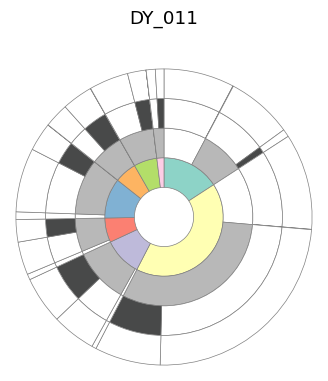

In [116]:
for m, mat in enumerate(sessions_to_process[:1]):
    mouse_name = mat[0]
    session = mat[1] 
    fit_id = str(mouse_name+session)
    # try:
    print(mouse_name,session)
    # Load session-specific file
    session_file_path = save_states_path + "states_file_" + str(session) + '_' + mouse_name
    states_trial = pd.read_parquet(session_file_path)
    init = 1205
    inter = 250

    identifiable_states = states_trial["identifiable_states"] #.dropna()
    digits = identifiable_states.str.extract(r'(\d)(\d)(\d)').astype('Int64')
    digits.columns = ["paw", "whisk", "lick"]
        
    states_trial['paw'] = digits['paw']
    states_trial['whisk'] = digits['whisk']
    states_trial['lick'] = digits['lick']
    states_trial['epoch'] = pd.factorize(states_trial['broader_label'])[0]
        
    trials_file = data_path + "session_trials_" + str(session) + '_'  + mouse_name
    session_trials = pd.read_parquet(trials_file, engine='pyarrow').reset_index() 
    
    # plot_state_heatmap_trials(states_trial, session, session_trials, n_trials=20, 
    #                         time_before=1.0, time_after=1.5, 
    #                         align_to='goCueTrigger_times')
    
    # raw_traces(init, inter, states_trial, session_trials)
    init = 1205
    inter = 1000
    # wheel_over_wavelet_clusters(init, inter, states_trial, session_trials)
    # init = 1205
    # inter = 300
    # psth_style_traces(init, inter, states_trial, session_trials)
    # except:
    #     print(mouse_name)
    fig, ax = plt.subplots(1, 1,figsize=(4,4), subplot_kw={'projection':'polar'})
    plot_single_polar_3(ax, states_trial, mouse_name)
    fig.savefig(prefix + 'representation_learning_variability/paper-individuality/figures/'+'polar_plot_example.svg', format='svg', bbox_inches='tight')

        

## Wavelets

In [ ]:
""" 
LOAD DATA AND PARAMETERS
"""
# LOAD DATA
var = 'paw'

data_path = prefix + 'representation_learning_variability/paper-individuality/data/design_matrices/'
all_files = os.listdir(data_path)
design_matrices = [item for item in all_files if 'design_matrix' in item and 'standardized' not in item]
idxs, mouse_names = idxs_from_files(design_matrices)

if var == 'paw':
    wavelet_path = prefix + 'representation_learning_variability/paper-individuality/data/paw_wavelets/'
elif var == 'wheel':
    wavelet_path = prefix + 'representation_learning_variability/paper-individuality/data/wheel_wavelets/'

velocity = True
# Loop through animals
files = os.listdir(wavelet_path)
sessions_to_process = []

for m, mat in enumerate(idxs):
    mouse_name = mat[37:]
    session = mat[:36]

    """ SAVE DATA """       
    # Save wavelets
    if var == 'paw':
        if velocity:
            subname = "paw_vel_wavelets_"
        else:
            subname = "paw_pos_wavelets_"
    elif var == 'wheel':
        subname = 'wheel_vel_wavelets_'
    
    filename = subname + str(session) + '_'  + mouse_name

    if filename in files:
        sessions_to_process.append((mouse_name, session))
    
print(len(sessions_to_process))

319


In [16]:
var_interest = ['l_paw_x', 'l_paw_y', 'r_paw_x', 'r_paw_y', 
                    'l_paw_x0.5', 'l_paw_x1.0', 'l_paw_x2.0', 'l_paw_x4.0', 'l_paw_x8.0', 'l_paw_x16.0', 'l_paw_x32.0',
                    'l_paw_y0.5', 'l_paw_y1.0', 'l_paw_y2.0', 'l_paw_y4.0', 'l_paw_y8.0', 'l_paw_y16.0', 'l_paw_y32.0',
                    'r_paw_x0.5', 'r_paw_x1.0', 'r_paw_x2.0', 'r_paw_x4.0', 'r_paw_x8.0', 'r_paw_x16.0', 'r_paw_x32.0',
                    'r_paw_y0.5', 'r_paw_y1.0', 'r_paw_y2.0', 'r_paw_y4.0', 'r_paw_y8.0', 'r_paw_y16.0', 'r_paw_y32.0']


In [17]:
assert len(sessions_to_process) == 319
for m, mat in enumerate(sessions_to_process[:1]):

    mouse_name = mat[0]
    session = mat[1]
    filename = wavelet_path + subname + str(session) + '_'  + mouse_name
    design_matrix = pd.read_parquet(filename)

    # Prepare data
    data_df = design_matrix[var_interest].copy().dropna()
    data = np.array(data_df)

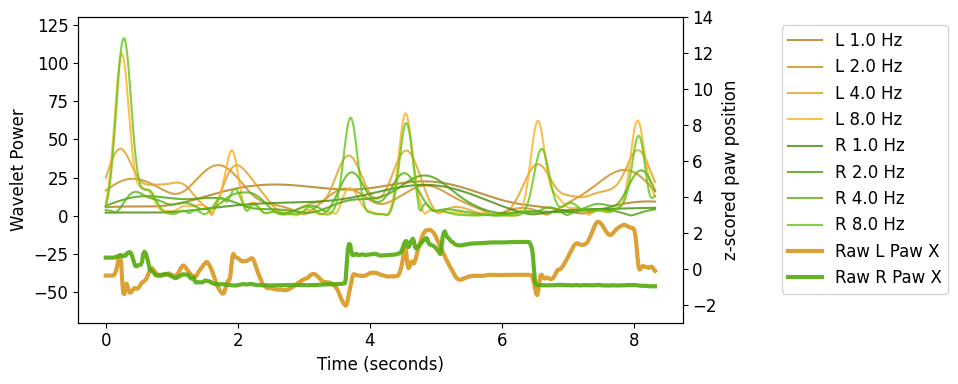

In [23]:
# Define frequencies and get data snippet (excluding 0.5, 16, and 32 Hz)
frequencies = [0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 32.0]
start_idx = 0
end_idx = min(500, data.shape[0])
time_snippet = np.arange(start_idx, end_idx) / 60  # Convert to seconds (60Hz sampling rate)
data_snippet = data[start_idx:end_idx]

# Create single subplot
fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
plt.rc('font', size=12, weight='normal')

# Generate color gradients
# Orange shades for left paw wavelets (lighter to darker orange)
left_paw_base = np.array([216, 151, 31]) / 255  # #C54B8C in RGB
pink_shades = []
for i in range(len(frequencies)):
    # Create lighter to darker shades
    shade_factor = 0.7 + 0.7 * (i / (len(frequencies) - 1))  # 0.3 to 1.0
    pink_shades.append(left_paw_base * shade_factor)

# Green shades for right paw wavelets (lighter to darker green)
right_paw_base = np.array([84, 170, 14]) / 255  # #468611 in RGB
green_shades = []
for i in range(len(frequencies)):
    # Create lighter to darker shades
    shade_factor = 0.7 + 0.7 * (i / (len(frequencies) - 1))  # 0.3 to 1.0
    green_shades.append(right_paw_base * shade_factor)

# Plot left paw wavelets
for freq_idx, freq in enumerate(frequencies):
    if freq in [0.5, 16.0, 32.0]:
        continue
    col_idx = 4 + freq_idx  # Left paw x wavelet starts at index 4
    ax1.plot(time_snippet, data_snippet[:, col_idx], 
           color=pink_shades[freq_idx], 
           label=f'L {freq} Hz', alpha=0.8, linewidth=1.5)

# Plot right paw wavelets
right_paw_wavelet_start = 4 + len(frequencies)  # Adjust this index based on your data structure
for freq_idx, freq in enumerate(frequencies):
    if freq in [0.5, 16.0, 32.0]:
        continue
    col_idx = right_paw_wavelet_start + freq_idx  # Right paw x wavelet data
    if col_idx < data.shape[1]:  # Check if index exists
        ax1.plot(time_snippet, data_snippet[:, col_idx], 
               color=green_shades[freq_idx], 
               label=f'R {freq} Hz', alpha=0.8, linewidth=1.5)

# Create secondary y-axis for raw paw data
ax1_right = ax1.twinx()

# Plot both raw paw traces
raw_left_paw_x = data_snippet[:, 0]/2  # Index 0 is l_paw_x
normalized_left_paw_x = (raw_left_paw_x - np.mean(raw_left_paw_x)) / np.std(raw_left_paw_x)

raw_right_paw_x = data_snippet[:, 2]  # Assuming index 2 is r_paw_x
normalized_right_paw_x = (raw_right_paw_x - np.mean(raw_right_paw_x)) / np.std(raw_right_paw_x)


ax1_right.plot(time_snippet, normalized_left_paw_x, 
              color="#D8971F", linewidth=3, label='Raw L Paw X', alpha=0.9)
ax1_right.plot(time_snippet, normalized_right_paw_x, 
              color="#54AA0E", linewidth=3, label='Raw R Paw X', alpha=0.9), 

# Set labels and colors
ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Wavelet Power', color='black')
ax1_right.set_ylabel('z-scored paw position', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1_right.tick_params(axis='y', labelcolor='black')

# Set y-axis limits
ax1_right.set_ylim([-3, 14])
ax1.set_ylim([-70, 130])

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_right.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, bbox_to_anchor=(1.15, 1), loc='upper left')

plt.tight_layout()   
fig.savefig(prefix+'representation_learning_variability/paper-individuality/figures/'+'wavelets.svg', format='svg', bbox_inches='tight')

plt.show()